# UI-curated ST-to-Allen-CCF alignment — MERFISH S2R1

This notebook consumes the pairing CSV downloaded from the spAlignDE
interactive region-pairing tool and runs ST-to-Allen alignment directly. The
example aligns adult mouse-brain MERFISH S2R1 (83,546 cells) to Allen CCF
coronal slice 675.

The UI output is the authoritative pair specification. This interface does
**not** rediscover candidates, calculate pair scores/gates or run pair
matching: each `group_id` is accepted directly as one many-to-many S-LDDMM
channel formed by the union of its selected ST clusters and Allen labels.
Individual CSV rows are selection records, not independent deformation
channels.

| Skipped because the UI already supplies pairs | Still performed for alignment |
|---|---|
| automatic Atlas candidate discovery | validate the CSV, slice and cluster IDs |
| pair metrics, score thresholds and gating | whole-mask pre-alignment, or consume separately prepared manual pre-alignment coordinates |
| greedy/non-overlap pair selection | point filtering and ST/Atlas mask construction |
| continuation-time pair rematching | mask cleanup, signed-distance conversion and global channel weighting |
| — | S-LDDMM input/grid construction, optimization, point mapping and Allen-label transfer |

The default example computes whole-mask pre-alignment. If manual
pre-alignment has already written `obs["x_prealigned"]` and
`obs["y_prealigned"]`, set `prealignment_mode="provided"`; every downstream
mask, processing and S-LDDMM stage remains unchanged.

**Fixed-seed reproducibility.** This workflow uses seed `1234`. Launch Python with `PYTHONHASHSEED` set before kernel startup, then keep the documented input order, package versions and configuration fixed. Discrete labels/pairs are expected to match exactly; CUDA coordinates are compared with the documented numerical tolerance.

## Installation and required inputs

From the repository root:

```bash
cd /path/to/spAlignDE
python -m pip install -e ".[clustering,atlas,tutorial]"
```

| Role | Input | Required contract |
|---|---|---|
| Query ST | clustered AnnData/H5AD | `obsm["spatial"]` and `obs["cluster"]`; cluster IDs must be exactly those shown in the UI when the pairs were exported |
| Curated correspondences | `spalign_de_experimental_pairs.csv` | the unedited CSV downloaded with **Export pairs**; retain `group_id`, panel dataset kinds, selected IDs and `atlas_z_slice` |
| Atlas annotation | `annotation_10.nrrd` | the same Allen CCF release and slice used in the UI |
| Atlas hierarchy | `voxel_count_and_differences.csv` | Allen annotation IDs, names, hierarchy paths and colors |

Create the pairing CSV first with the **Interactive region pairing and
refinement** source notebook linked from the Cross-Modality documentation. The
included UI guide explains how to select raw or custom regions, place several
selections in one group and export the result.

The example files under `tutorials/cross_modality/atlas/data/` preserve the
paper run. For a new dataset, set `SPALIGNDE_CLUSTERED_ST_H5AD`,
`SPALIGNDE_UI_PAIRING_CSV` and `SPALIGNDE_ALLEN_CCF_DIR`. The UI display's
flip/rotation fields are retained as provenance. They do not replace the
chosen global initialization: use `prealignment_mode="mask"` to recompute it,
or `"provided"` to consume manual pre-aligned coordinates.

In [1]:
%matplotlib inline

from pathlib import Path
import json
import os
import time
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

import spAlignDE

WORKFLOW_SEED = 1234
seed_controls = spAlignDE.set_random_seed(
    WORKFLOW_SEED,
    deterministic_torch=True,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from the spAlignDE repository.")


PROJECT_ROOT = find_project_root(Path.cwd())
ATLAS_TUTORIAL_DIR = PROJECT_ROOT / "tutorials" / "cross_modality" / "atlas"
DATA_DIR = ATLAS_TUTORIAL_DIR / "data"
OUTPUT_DIR = ATLAS_TUTORIAL_DIR / "output" / "ui_paired_alignment"
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

clustered_default = ATLAS_TUTORIAL_DIR / "output" / "merfish_S2R1_single_clustered.h5ad"
CLUSTERED_PATH = Path(
    os.environ.get("SPALIGNDE_CLUSTERED_ST_H5AD", clustered_default)
).expanduser()
PAIRING_PATH = Path(
    os.environ.get(
        "SPALIGNDE_UI_PAIRING_CSV",
        DATA_DIR / "spalign_de_experimental_pairs.csv",
    )
).expanduser()

public_atlas_dir = PROJECT_ROOT / "data" / "allen_ccf_2022"
ATLAS_DIR = Path(
    os.environ.get("SPALIGNDE_ALLEN_CCF_DIR", public_atlas_dir)
).expanduser()

required_atlas_files = [
    ATLAS_DIR / "annotation_10.nrrd",
    ATLAS_DIR / "voxel_count_and_differences.csv",
]
missing_atlas_files = [str(path) for path in required_atlas_files if not path.is_file()]
if missing_atlas_files:
    raise FileNotFoundError(
        "Allen CCF inputs are missing. Place them under data/allen_ccf_2022 "
        "or set SPALIGNDE_ALLEN_CCF_DIR. Missing: " + ", ".join(missing_atlas_files)
    )

print("Clustered ST:", CLUSTERED_PATH)
print("UI pairing CSV:", PAIRING_PATH)
print("Allen CCF directory:", ATLAS_DIR)

Clustered ST: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/merfish_S2R1_single_clustered.h5ad
UI pairing CSV: /path/to/spAlignDE/tutorials/cross_modality/atlas/data/spalign_de_experimental_pairs.csv
Allen CCF directory: /path/to/allen_ccf_2022


## Load the exact ST labels used by the UI

Pairing IDs are categorical identifiers, not transferable biological names.
Changing the clustering seed, refinement or resolution can renumber clusters
even when cell coordinates are unchanged. Therefore a UI export must be used
with the exact clustered AnnData uploaded to that UI session.

The checked-in paper example predates the current single-clustering notebook,
so the next cell restores its exact `banksy_cluster_refined` labels by
`cell_id`. This compatibility step runs automatically only for the default
tutorial H5AD. A user-supplied H5AD is never overwritten. Set
`SPALIGNDE_UI_CLUSTER_METADATA_CSV` only when an equivalent cell-indexed label
table is intentionally required.

In [2]:
adata = spAlignDE.load_single_sample_data(CLUSTERED_PATH)

metadata_override = os.environ.get("SPALIGNDE_UI_CLUSTER_METADATA_CSV")
example_metadata = DATA_DIR / "ui_example_st_clusters.csv"
use_example_metadata = (
    metadata_override is None
    and CLUSTERED_PATH.resolve() == clustered_default.resolve()
    and example_metadata.is_file()
)
metadata_path = Path(metadata_override).expanduser() if metadata_override else (
    example_metadata if use_example_metadata else None
)

if metadata_path is not None:
    exact_metadata = pd.read_csv(metadata_path, dtype={"cell_id": str}).set_index("cell_id")
    exact_metadata.index = exact_metadata.index.astype(str)
    missing_cells = adata.obs_names.astype(str).difference(exact_metadata.index)
    if len(missing_cells):
        raise ValueError(
            f"Cluster metadata is missing {len(missing_cells):,} AnnData cell IDs."
        )
    exact_labels = exact_metadata.reindex(adata.obs_names.astype(str))[
        "banksy_cluster_refined"
    ]
    if exact_labels.isna().any():
        raise ValueError("The exact UI cluster metadata contains missing labels.")
    adata.obs["cluster"] = exact_labels.astype(str).to_numpy()
    adata.obs["cluster"] = adata.obs["cluster"].astype("category")
    print("Restored the exact cluster labels used by the validated UI export.")
else:
    spAlignDE.validate_single_sample_anndata(
        adata,
        cluster_key="cluster",
        require_cluster=True,
    )
    print("Using cluster labels directly from the supplied AnnData.")

atlas = spAlignDE.load_allen_ccf_reference(
    ATLAS_DIR / "annotation_10.nrrd",
    ATLAS_DIR / "voxel_count_and_differences.csv",
    slice_index=675,
)

print(f"Query: {adata.n_obs:,} cells; {adata.obs['cluster'].nunique()} clusters")
print(f"Reference: Allen CCF slice {atlas.slice_index}; image shape {atlas.shape}")

Restored the exact cluster labels used by the validated UI export.


Query: 83,546 cells; 25 clusters
Reference: Allen CCF slice 675; image shape (800, 1140)


## Inspect and validate the UI export

`load_ui_atlas_pairing` determines which panel is ST from the retained
`*_dataset_kind` columns, checks the Allen slice, expands custom regions back
to their original selected IDs and reconstructs the many-to-many groups. This
is parsing and validation only; it does not score or rematch a pair.

This example contains 54 selection rows, 9 deformation groups and 11 ST
cluster-level records for plotting and provenance. Several rows may describe
the same group because a group can contain multiple ST clusters and multiple
Allen structures.

In [3]:
pairing = spAlignDE.load_ui_atlas_pairing(
    PAIRING_PATH,
    expected_atlas_slice=atlas.slice_index,
)

ui_cluster_ids = {
    str(cluster_id)
    for values in pairing.deformation_groups["st_cluster_ids"]
    for cluster_id in values
}
available_cluster_ids = set(adata.obs["cluster"].astype(str))
missing_cluster_ids = sorted(ui_cluster_ids.difference(available_cluster_ids))
if missing_cluster_ids:
    raise ValueError(
        "The AnnData cluster labels do not match the UI export. "
        f"Missing IDs: {missing_cluster_ids}"
    )

pairing_summary = pd.Series(
    {
        "raw UI rows": len(pairing.raw),
        "S-LDDMM deformation groups": len(pairing.deformation_groups),
        "ST cluster-level output pairs": len(pairing.matched_pairs),
        "ST panel": pairing.st_side,
        "Allen slice": pairing.atlas_slice_index,
    },
    name="value",
)
display(pairing_summary.to_frame())
display(
    pairing.deformation_groups[
        ["group_id", "st_cluster_ids", "atlas_labels_union", "candidate_name"]
    ]
)

,value
raw UI rows,54
S-LDDMM deformation groups,9
ST cluster-level output pairs,11
ST panel,left
Allen slice,675


,group_id,st_cluster_ids,atlas_labels_union,candidate_name
0,group_1,[2],"[163, 201, 430, 434, 670, 806, 965, 1106, 3127...",RSPv2/3;RSPd2/3;RSPagl2/3;VISa2/3;SSp-tr2/3;SS...
1,group_2,[5],"[1010, 1035, 1047, 1086, 182305701]",SSp-tr4;SSp-un4;SSp-bfd4;SSs4;VISC4
2,group_3,[3],"[344, 610, 625, 687, 774, 1058, 1070, 1090, 11...",RSPd5;RSPv5;RSPagl5;SSp-tr5;SSp-ul5;SSp-un5;SS...
3,group_4,[0],"[9, 274, 314, 478, 590, 857, 862, 906, 945, 10...",RSPv6a;RSPd6a;RSPagl6a;SSp-tr6a;SSp-ul6a;SSp-l...
4,group_5,"[18, 19, 20]","[407, 495, 632]",CA1sp;DG-sg;CA3sp
5,group_6,[17],"[186, 483]",MH;LH
6,group_7,[7],[672],CP
7,group_8,[6],"[194, 436, 803, 830, 1097, 576073704]",HY;LHA;PAL;PeF;fx;DMH
8,group_9,[13],[262],RT


## Configure the UI-curated S-LDDMM run

The values below reproduce the validated UI-based example. Public names are
shown next to their legacy notebook symbols:

- `kernel_scale=200` (`a`) controls the spatial scale and smoothness of the
  deformation. Increase it for a broader, smoother field; decrease it only
  when reproducible local bends remain unresolved.
- `velocity_grid_spacing=50` (`grid_step`) controls deformation resolution.
  Smaller spacing adds control points and costs more GPU memory; larger
  spacing is faster and more regularized.
- `time_steps=5` (`nt`) controls numerical integration accuracy.
- `iterations=500` (`niter`) is increased only when the energy is still
  falling at the final iteration.
- `restore_best_checkpoint=False` preserves the transformation at iteration
  500 and reproduces the validated paper run. For exploratory data, setting it
  to `True` returns the lowest-energy checkpoint instead.

Mask preprocessing, signed-distance scaling and area balancing are global:
they apply identically to every region group. There is no hippocampus- or
structure-name-specific weight. Inspect group masks and whole-tissue
pre-alignment before changing deformation parameters.

In [4]:
config = spAlignDE.UIAtlasAlignmentConfig(
    prealignment_mode="mask",  # use "provided" for manual x/y_prealigned columns
    kernel_scale=200,
    time_steps=5,
    velocity_grid_spacing=50,
    iterations=500,
    momentum_learning_rate=2000,
    raster_zoom_scale=0.6,
    restore_best_checkpoint=False,
    device=None,  # CUDA when available, otherwise CPU
    verbose=True,
)

display(
    pd.Series(
        {
            "prealignment_mode": config.prealignment_mode,
            "kernel_scale (a)": config.kernel_scale,
            "velocity_grid_spacing (grid_step)": config.velocity_grid_spacing,
            "time_steps (nt)": config.time_steps,
            "iterations (niter)": config.iterations,
            "momentum_learning_rate (lrM)": config.momentum_learning_rate,
            "restore_best_checkpoint": config.restore_best_checkpoint,
        },
        name="value",
    ).to_frame()
)

,value
prealignment_mode,mask
kernel_scale (a),200
velocity_grid_spacing (grid_step),50
time_steps (nt),5
iterations (niter),500
momentum_learning_rate (lrM),2000
restore_best_checkpoint,False


### Optional manual pre-alignment handoff

Manual pre-alignment is an alternative global initialization, not another pair
matching step. After an interactive/manual transform has populated the
standard coordinate columns, change only the configuration:

```python
manual_config = spAlignDE.UIAtlasAlignmentConfig(
    prealignment_mode="provided",
    provided_prealigned_x_key="x_prealigned",
    provided_prealigned_y_key="y_prealigned",
    kernel_scale=200,
    velocity_grid_spacing=50,
    iterations=500,
)
```

The function then skips whole-mask transform estimation but still filters
points, rebuilds ST and Allen masks, applies mask processing, constructs the
S-LDDMM input channels and runs the final deformation. The executable paper
example below continues with `prealignment_mode="mask"`.

## Run alignment directly from the exported CSV

No notebook-local alignment function or subprocess is required. The package
uses the selected global initialization, then constructs one unioned
signed-distance channel per valid UI group, performs one S-LDDMM stage, maps
all cells and samples Allen labels at the final coordinates. It never invokes
the automatic pair-matching pipeline.

[area-only gate] mode=bbox, q=0.4, threshold=2699139.472, n_detail=10


[LDDMM] start: niter=500, nt=5, device=cuda:0, I_shape=(10, 480, 684), J_shape=(10, 480, 684)


[LDDMM] iter 1/500 E=2.013488e+04 EM=2.013488e+04 ER=0.000000e+00


[LDDMM] iter 101/500 E=2.845046e+04 EM=2.844697e+04 ER=3.482219e+00


[LDDMM] iter 201/500 E=2.672929e+04 EM=2.672434e+04 ER=4.949710e+00


[LDDMM] iter 301/500 E=2.523659e+04 EM=2.522995e+04 ER=6.640941e+00


[LDDMM] iter 401/500 E=2.452699e+04 EM=2.451900e+04 ER=7.986881e+00


[LDDMM] iter 500/500 E=2.414140e+04 EM=2.413230e+04 ER=9.107905e+00
[LDDMM] done in 91.5s. finalE=2.414140e+04


label column: cluster
points in view before/after: 83546 / 83546 of 83546
matched pairs shown: 11


saved result visualization PNG: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/ui_paired_alignment/iterative_lddmm_before_after_all_points.png
saved result visualization PDF: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/ui_paired_alignment/iterative_lddmm_before_after_all_points.pdf


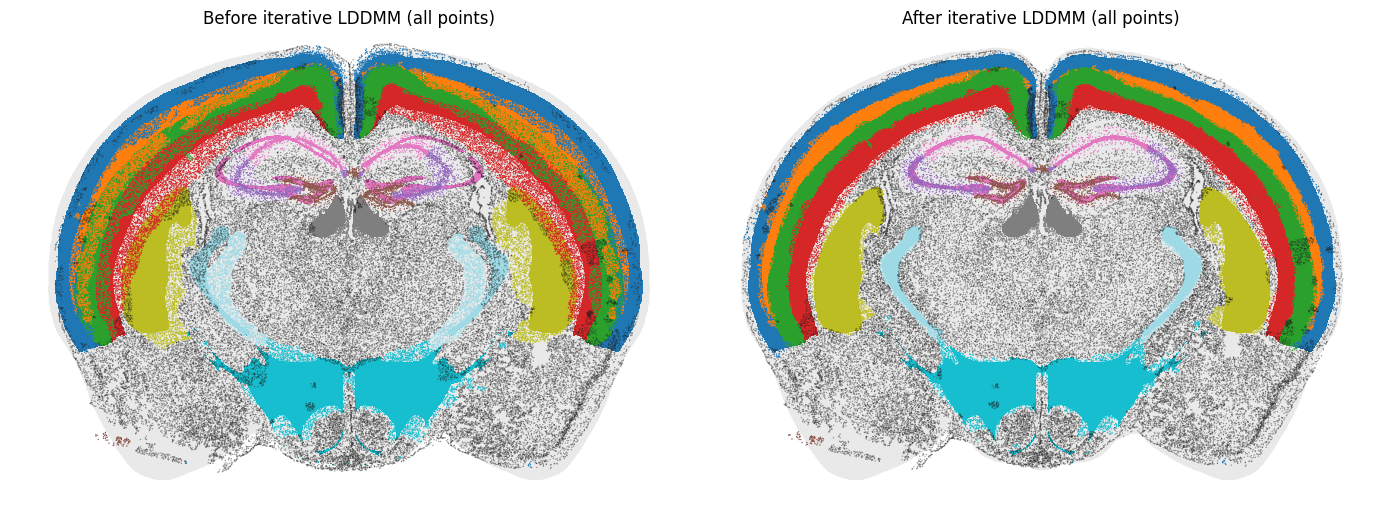

saved final alignment outputs to: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/ui_paired_alignment
final aligned points: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/ui_paired_alignment/final_aligned_all_points.csv
final matched pairs: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/ui_paired_alignment/matched_pairs_final_stage.csv
all-stage matched pairs: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/ui_paired_alignment/matched_pairs_all_stages.csv
stage summary: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/ui_paired_alignment/iterative_alignment_stage_summary.csv


,stage,label_col,is_final_stage,n_pairs,n_manual_groups,pair_source,pair_matching_ran,mask_construction_ran,lddmm_input_built,lddmm_ran
0,1,cluster,True,11,9,ui_export,False,True,True,True


Aligned observations: 83,546
Wall-clock runtime: 1.92 minutes
Peak CUDA memory allocated: 0.446 GiB


In [5]:
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

started = time.perf_counter()
result = spAlignDE.align_st_to_allen_atlas_from_ui_pairs(
    adata,
    atlas,
    pairing,
    config=config,
    cluster_key="cluster",
    spatial_key="spatial",
    output_dir=OUTPUT_DIR,
    save_outputs=True,
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed_seconds = time.perf_counter() - started
peak_gib = (
    torch.cuda.max_memory_allocated() / 1024**3
    if torch.cuda.is_available()
    else None
)
runtime_metrics = {
    "elapsed_seconds": elapsed_seconds,
    "elapsed_minutes": elapsed_seconds / 60,
    "peak_cuda_memory_allocated_gib": peak_gib,
    "n_cells": result.adata.n_obs,
    "n_ui_rows": len(pairing.raw),
    "n_ui_groups": len(pairing.deformation_groups),
    "n_output_pairs": len(result.matched_pairs),
}
(OUTPUT_DIR / "notebook_runtime_metrics.json").write_text(
    json.dumps(runtime_metrics, indent=2)
)

display(result.stage_summary)
print(f"Aligned observations: {result.adata.n_obs:,}")
print(f"Wall-clock runtime: {elapsed_seconds / 60:.2f} minutes")
if peak_gib is not None:
    print(f"Peak CUDA memory allocated: {peak_gib:.3f} GiB")

## Review the curated correspondence table

The result table has one row per selected ST cluster, while
`n_manual_groups` reports the actual number of S-LDDMM channels. Use the saved
`manual_pairs_grouped_valid_for_lddmm.csv` to audit which requested ST and
Allen IDs were present in this run. `result.matched_pairs` is retained as the
standard result-field name, but here it is a normalized copy of UI-accepted
pairs—not the output of a new matching calculation. The stage summary records
`pair_matching_ran=False` explicitly.

In [6]:
pair_columns = [
    "group_id",
    "cluster",
    "st_cluster_ids",
    "atlas_labels_union",
    "candidate_name",
    "pair_type",
]
display(result.matched_pairs[pair_columns])

,group_id,cluster,st_cluster_ids,atlas_labels_union,candidate_name,pair_type
0,group_1,2,[2],"[163, 201, 430, 434, 670, 806, 965, 1106, 3127...",RSPv2/3;RSPd2/3;RSPagl2/3;VISa2/3;SSp-tr2/3;SS...,ui_manual_cluster
1,group_2,5,[5],"[1010, 1035, 1047, 1086, 182305701]",SSp-tr4;SSp-un4;SSp-bfd4;SSs4;VISC4,ui_manual_cluster
2,group_3,3,[3],"[344, 610, 625, 687, 774, 1058, 1070, 1090, 11...",RSPd5;RSPv5;RSPagl5;SSp-tr5;SSp-ul5;SSp-un5;SS...,ui_manual_cluster
3,group_4,0,[0],"[9, 274, 314, 478, 590, 857, 862, 906, 945, 10...",RSPv6a;RSPd6a;RSPagl6a;SSp-tr6a;SSp-ul6a;SSp-l...,ui_manual_cluster
4,group_5,18,[18],"[407, 495, 632]",CA1sp;DG-sg;CA3sp,ui_manual_cluster
5,group_5,19,[19],"[407, 495, 632]",CA1sp;DG-sg;CA3sp,ui_manual_cluster
6,group_5,20,[20],"[407, 495, 632]",CA1sp;DG-sg;CA3sp,ui_manual_cluster
7,group_6,17,[17],"[186, 483]",MH;LH,ui_manual_cluster
8,group_7,7,[7],[672],CP,ui_manual_cluster
9,group_8,6,[6],"[194, 436, 803, 830, 1097, 576073704]",HY;LHA;PAL;PeF;fx;DMH,ui_manual_cluster


## Before and after UI-curated alignment

The left panel is the package-recomputed whole-mask pre-alignment. The right
panel is the final S-LDDMM result. ST clusters that share one UI group undergo
one common union-mask constraint; the plot retains cluster-level rows so the
selected structures remain interpretable.

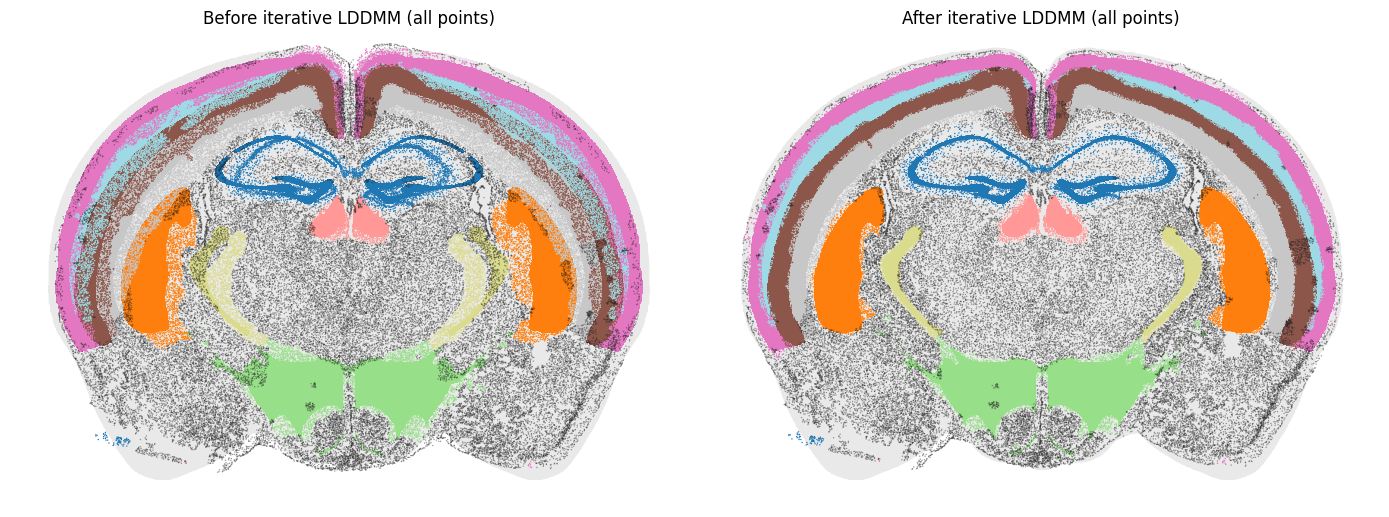

In [7]:
structure_color_map = spAlignDE.load_atlas_structure_color_map()
fig, axes = spAlignDE.plot_st_atlas_alignment(
    result,
    cluster_key="cluster",
    structure_color_map=structure_color_map,
    point_size=1.0,
    figsize=(14, 7),
)
fig.savefig(FIGURE_DIR / "ui_st_to_allen_before_after.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "ui_st_to_allen_before_after.svg", bbox_inches="tight")
plt.show()

## Transfer Allen labels to aligned cells

Each final `(x_aligned, y_aligned)` point samples Allen slice 675. Atlas label
0 remains background/unlabeled. The annotation and transferred-cell panels
use the same deterministic Allen label-ID palette.

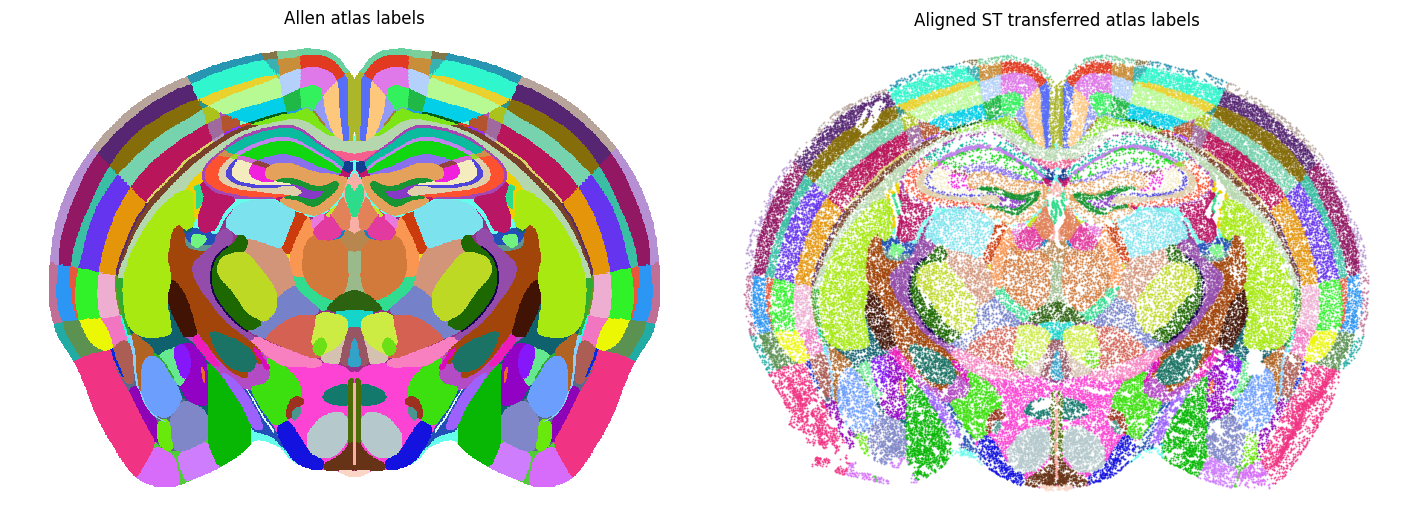

,value
all ST cells,83546
non-background Allen label,83236
background / unlabeled,310


In [8]:
color_map_path = result.output_dir / (
    f"atlas_z{result.atlas.slice_index}_white_label_color_map_for_transfer_labels.csv"
)
label_color_map = spAlignDE.load_atlas_label_color_map(
    color_map_path,
    atlas=result.atlas,
)
fig, axes = spAlignDE.plot_atlas_label_transfer(
    result,
    color_map=label_color_map,
    point_size=2.0,
    point_alpha=0.8,
    figsize=(14, 7),
)
fig.savefig(FIGURE_DIR / "ui_st_to_allen_label_transfer.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "ui_st_to_allen_label_transfer.svg", bbox_inches="tight")
plt.show()

transfer_summary = pd.Series(
    {
        "all ST cells": result.adata.n_obs,
        "non-background Allen label": int(
            result.adata.obs["atlas_label_transferred"].sum()
        ),
        "background / unlabeled": int(
            (~result.adata.obs["atlas_label_transferred"]).sum()
        ),
    },
    name="value",
)
display(transfer_summary.to_frame())

## Output contract and troubleshooting

The returned AnnData preserves `X` and `obsm["spatial"]` and adds
`x_prealigned`, `y_prealigned`, `x_aligned`, `y_aligned` plus Allen label
columns to `obs`. Provenance is stored under
`uns["spAlignDE"]["st_to_allen_atlas"]` with
`pairing_mode="ui_curated"`. The output directory also contains the aligned
H5AD, raw/grouped/valid pair tables, coordinate table, filtering statistics
and alignment figures.

Common failures:

- **Missing ST IDs:** use the exact clustered AnnData uploaded to the UI; do
  not assume a rerun preserves integer cluster labels.
- **Atlas slice mismatch:** reload the slice recorded in `atlas_z_slice`; do
  not silently edit the CSV.
- **A group is skipped:** inspect
  `manual_pairs_grouped_valid_for_lddmm.csv`; a requested ST mask or Allen ID
  may be absent after filtering/on the selected slice.
- **Poor global placement:** improve whole-mask pre-alignment or provide
  manually pre-aligned coordinates before decreasing `kernel_scale` or grid
  spacing.
- **Overly local deformation:** increase `kernel_scale` or
  `velocity_grid_spacing`; keep weighting changes global rather than assigning
  anatomy-specific exceptions.

In [9]:
coordinate_columns = ["x_prealigned", "y_prealigned", "x_aligned", "y_aligned"]
label_columns = [
    "atlas_label_id",
    "atlas_label_acronym",
    "atlas_label_name",
    "atlas_label_transferred",
]
display(result.adata.obs[coordinate_columns + label_columns].head())
print("Pairing mode:", result.adata.uns["spAlignDE"]["st_to_allen_atlas"]["pairing_mode"])
print("Saved output:", result.output_dir)

,x_prealigned,y_prealigned,x_aligned,y_aligned,atlas_label_id,atlas_label_acronym,atlas_label_name,atlas_label_transferred
cell_id,,,,,,,,
149164679103246548309819743981609972453,10070.702197,2047.091006,10053.247874,1984.422550,961,PIR,Piriform area,True
215843146921706462965382248182021894607,10140.473843,2117.309107,10121.309065,2041.676895,961,PIR,Piriform area,True
230248905804673613678286091156141465134,10122.405859,2064.660145,10105.528779,1998.254705,961,PIR,Piriform area,True
237155298815097057940587033798543926454,10093.291263,2023.639780,10077.982629,1964.480044,961,PIR,Piriform area,True
256099454901769634241742157204636917386,10099.394726,2029.208897,10083.921891,1969.028524,961,PIR,Piriform area,True


Pairing mode: ui_curated
Saved output: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/ui_paired_alignment
